1.Import Libraries

In [15]:
# Import required libraries for preprocessing
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE


2.Load Raw Dataset

In [16]:
import os

# List all CSV files in the current directory and subdirectories
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))


.\data\processed\agglomerative_clustered_data.csv
.\data\processed\agglomerative_cluster_labels.csv
.\data\processed\cleaned1_clustering.csv
.\data\processed\cleaned2_no_outliers.csv
.\data\processed\clustered_data.csv
.\data\processed\dbscan_clustered_data.csv
.\data\processed\dbscan_cluster_labels.csv
.\data\processed\encoded_clustering.csv
.\data\processed\fifa21_clean.csv
.\data\processed\final_preprocessed_clustering.csv
.\data\processed\gmm_clustered_data.csv
.\data\processed\gmm_cluster_labels.csv
.\data\processed\kmeans_cluster_labels.csv
.\data\processed\X_test_diabetes.csv
.\data\processed\X_train_diabetes.csv
.\data\processed\y_pred_dt.csv
.\data\processed\y_pred_lr.csv
.\data\processed\y_pred_nb.csv
.\data\processed\y_pred_svm.csv
.\data\processed\y_proba_dt.csv
.\data\processed\y_proba_lr.csv
.\data\processed\y_proba_nb.csv
.\data\processed\y_proba_svm.csv
.\data\processed\y_test_diabetes.csv
.\data\processed\y_train_diabetes.csv
.\data\raw\diabetes.csv
.\data\raw\fifa21_r

In [17]:
# Load raw diabetes dataset
import pandas as pd
import os

# Correct relative path to the file
file_path = r"data/raw/diabetes.csv"

# Check if the file exists
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    
    # Print dataset shape
    print("Shape:", df.shape)
    
    # Display first 5 rows
    display(df.head())
    
    # Display info about columns, data types, and missing values
    display(df.info())
    
    # Display statistical summary for numerical columns
    display(df.describe())
else:
    print(f"Error: File not found at {file_path}. Please check the path.")


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


3.Missing Values Overview

In [18]:
# Check missing values
missing_count = df.isna().sum()
missing_percent = 100 * missing_count / len(df)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
})

display(missing_df)


,Missing Count,Missing %
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


4.Handle Zero Values as Missing

In [19]:
# Convert 0 values to NaN for selected columns
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

display(df[cols_with_zero].isna().sum())


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

5.Impute Missing Values

In [20]:
# Impute missing values with median
imputer = SimpleImputer(strategy='median')

df[cols_with_zero] = imputer.fit_transform(df[cols_with_zero])

display(df.isna().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

6.Outlier Handling (IQR Capping)

In [21]:
# Cap outliers using IQR
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

num_cols = df.drop('Outcome', axis=1).columns

for col in num_cols:
    cap_outliers(df, col)


7.Feature / Target Split

In [22]:
# Split dataset into features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (768, 8)
Target shape: (768,)


8.Feature Scaling

In [23]:
# Standardize features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

display(X_scaled.head())


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.647150,0.866045,-0.030632,0.824667,0.039062,0.181092,0.588927,1.445691
1,-0.848970,-1.205066,-0.543914,0.017945,0.039062,-0.869465,-0.378101,-0.189304
2,1.245598,2.016662,-0.715008,0.017945,0.039062,-1.364728,0.746595,-0.103252
3,-0.848970,-1.073567,-0.543914,-0.788777,-1.494110,-0.644346,-1.022787,-1.049828
4,-1.148194,0.504422,-2.768136,0.824667,1.414175,1.606849,2.596563,-0.017199


9.Train/Test Split

In [24]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (614, 8)
X_test: (154, 8)


10.Handle Class Imbalance (SMOTE)

In [25]:
# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)


After SMOTE:
X_train: (800, 8)
y_train: (800,)


11.Save Preprocessed Data

In [26]:
# Save preprocessed datasets
os.makedirs('data/processed', exist_ok=True)

X_train.to_csv('data/processed/X_train_diabetes.csv', index=False)
X_test.to_csv('data/processed/X_test_diabetes.csv', index=False)
y_train.to_csv('data/processed/y_train_diabetes.csv', index=False)
y_test.to_csv('data/processed/y_test_diabetes.csv', index=False)

print("Preprocessed diabetes data saved successfully!")


Preprocessed diabetes data saved successfully!


12.Final Check

In [27]:
# Final check of dataset shapes and class distribution
print("Final Dataset Shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

y_train.value_counts(normalize=True)


Final Dataset Shapes:
X_train: (800, 8)
X_test: (154, 8)
y_train: (800,)
y_test: (154,)


Outcome
0    0.5
1    0.5
Name: proportion, dtype: float64

13.Visualizations (Diabetes Dataset)

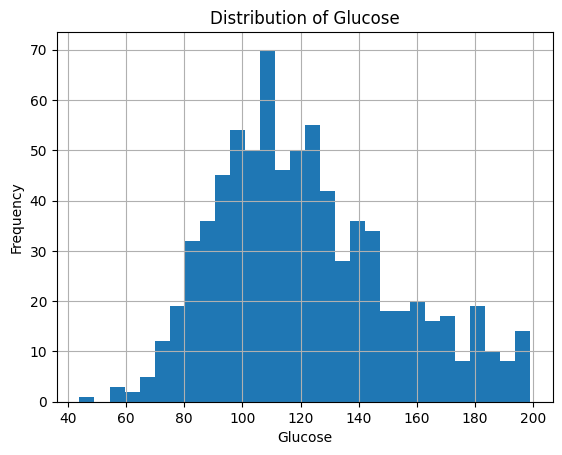

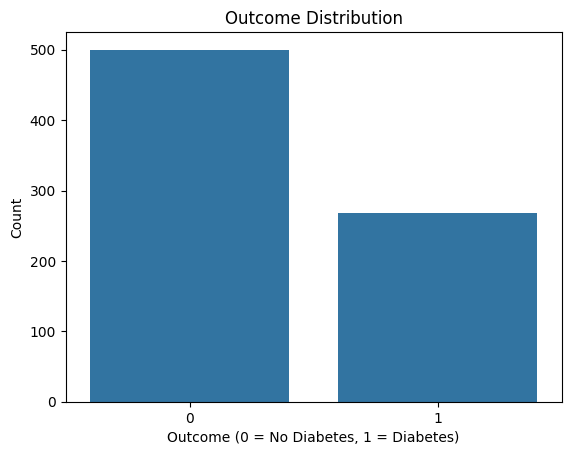

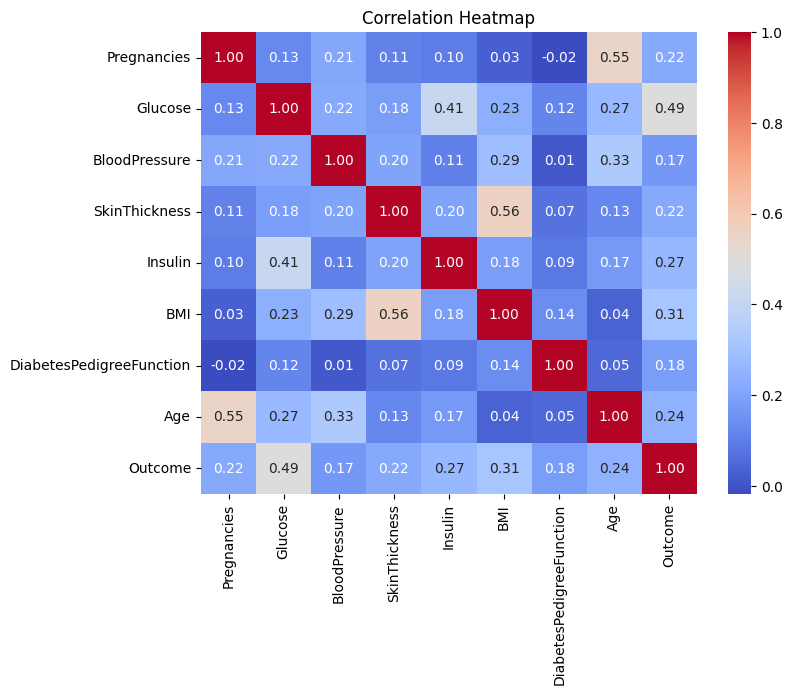

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder for figures
os.makedirs("results/figures", exist_ok=True)

# Glucose Distribution
plt.figure()
df['Glucose'].hist(bins=30)
plt.title('Distribution of Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.savefig('results/figures/glucose_distribution.png')
plt.show()


# Outcome (Target) Distribution
plt.figure()
sns.countplot(x='Outcome', data=df)
plt.title('Outcome Distribution')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.savefig('results/figures/outcome_distribution.png')
plt.show()


# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('results/figures/correlation_heatmap.png')
plt.show()
